In [23]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split

In [24]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [25]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0,No Anomaly


### K-Means

In [26]:
dataframe_data = dataframe.drop(columns=["description"])
dataframe_data

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0


In [27]:
kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

,n_clusters,14
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [30]:
combined = zip(dataframe.anomaly.values, dataframe.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
anomaly_ids

{np.float64(0.0): 'No Anomaly',
 np.float64(1.0): 'Sharp - Rotor Imbalance',
 np.float64(2.0): 'Linear - Rotor Imbalance',
 np.float64(3.0): 'Step - Rotor Imbalance',
 np.float64(4.0): 'Dirac - Rotor Imbalance',
 np.float64(5.0): 'Exponential - Rotor Imbalance',
 np.float64(6.0): 'Slow Water Increase (Circuit)',
 np.float64(7.0): 'Sharp Water Increase (Circuit)',
 np.float64(8.0): 'Water Drainage (Cavitation)',
 np.float64(9.0): 'Two-phase Supply (Cavitation)',
 np.float64(10.0): 'Water Temperature Increase',
 np.float64(11.0): 'Fluid Leaks',
 np.float64(12.0): 'Inlet Valve Malfunction',
 np.float64(13.0): 'Outlet Valve Malfunction'}

In [33]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 2329 times
1 occurs 7314 times
2 occurs 2063 times
3 occurs 6026 times
4 occurs 3215 times
5 occurs 76 times
6 occurs 1185 times
7 occurs 8491 times
8 occurs 3683 times
9 occurs 3718 times
10 occurs 2925 times
11 occurs 4470 times
12 occurs 1283 times
13 occurs 2424 times


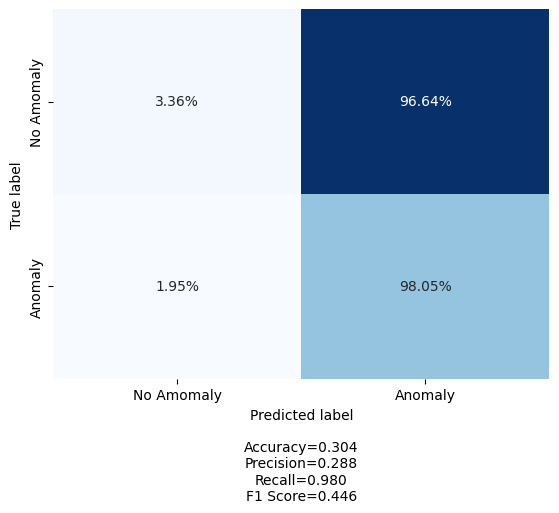

In [104]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_data.anomaly.values, kmeans_custom.labels_)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

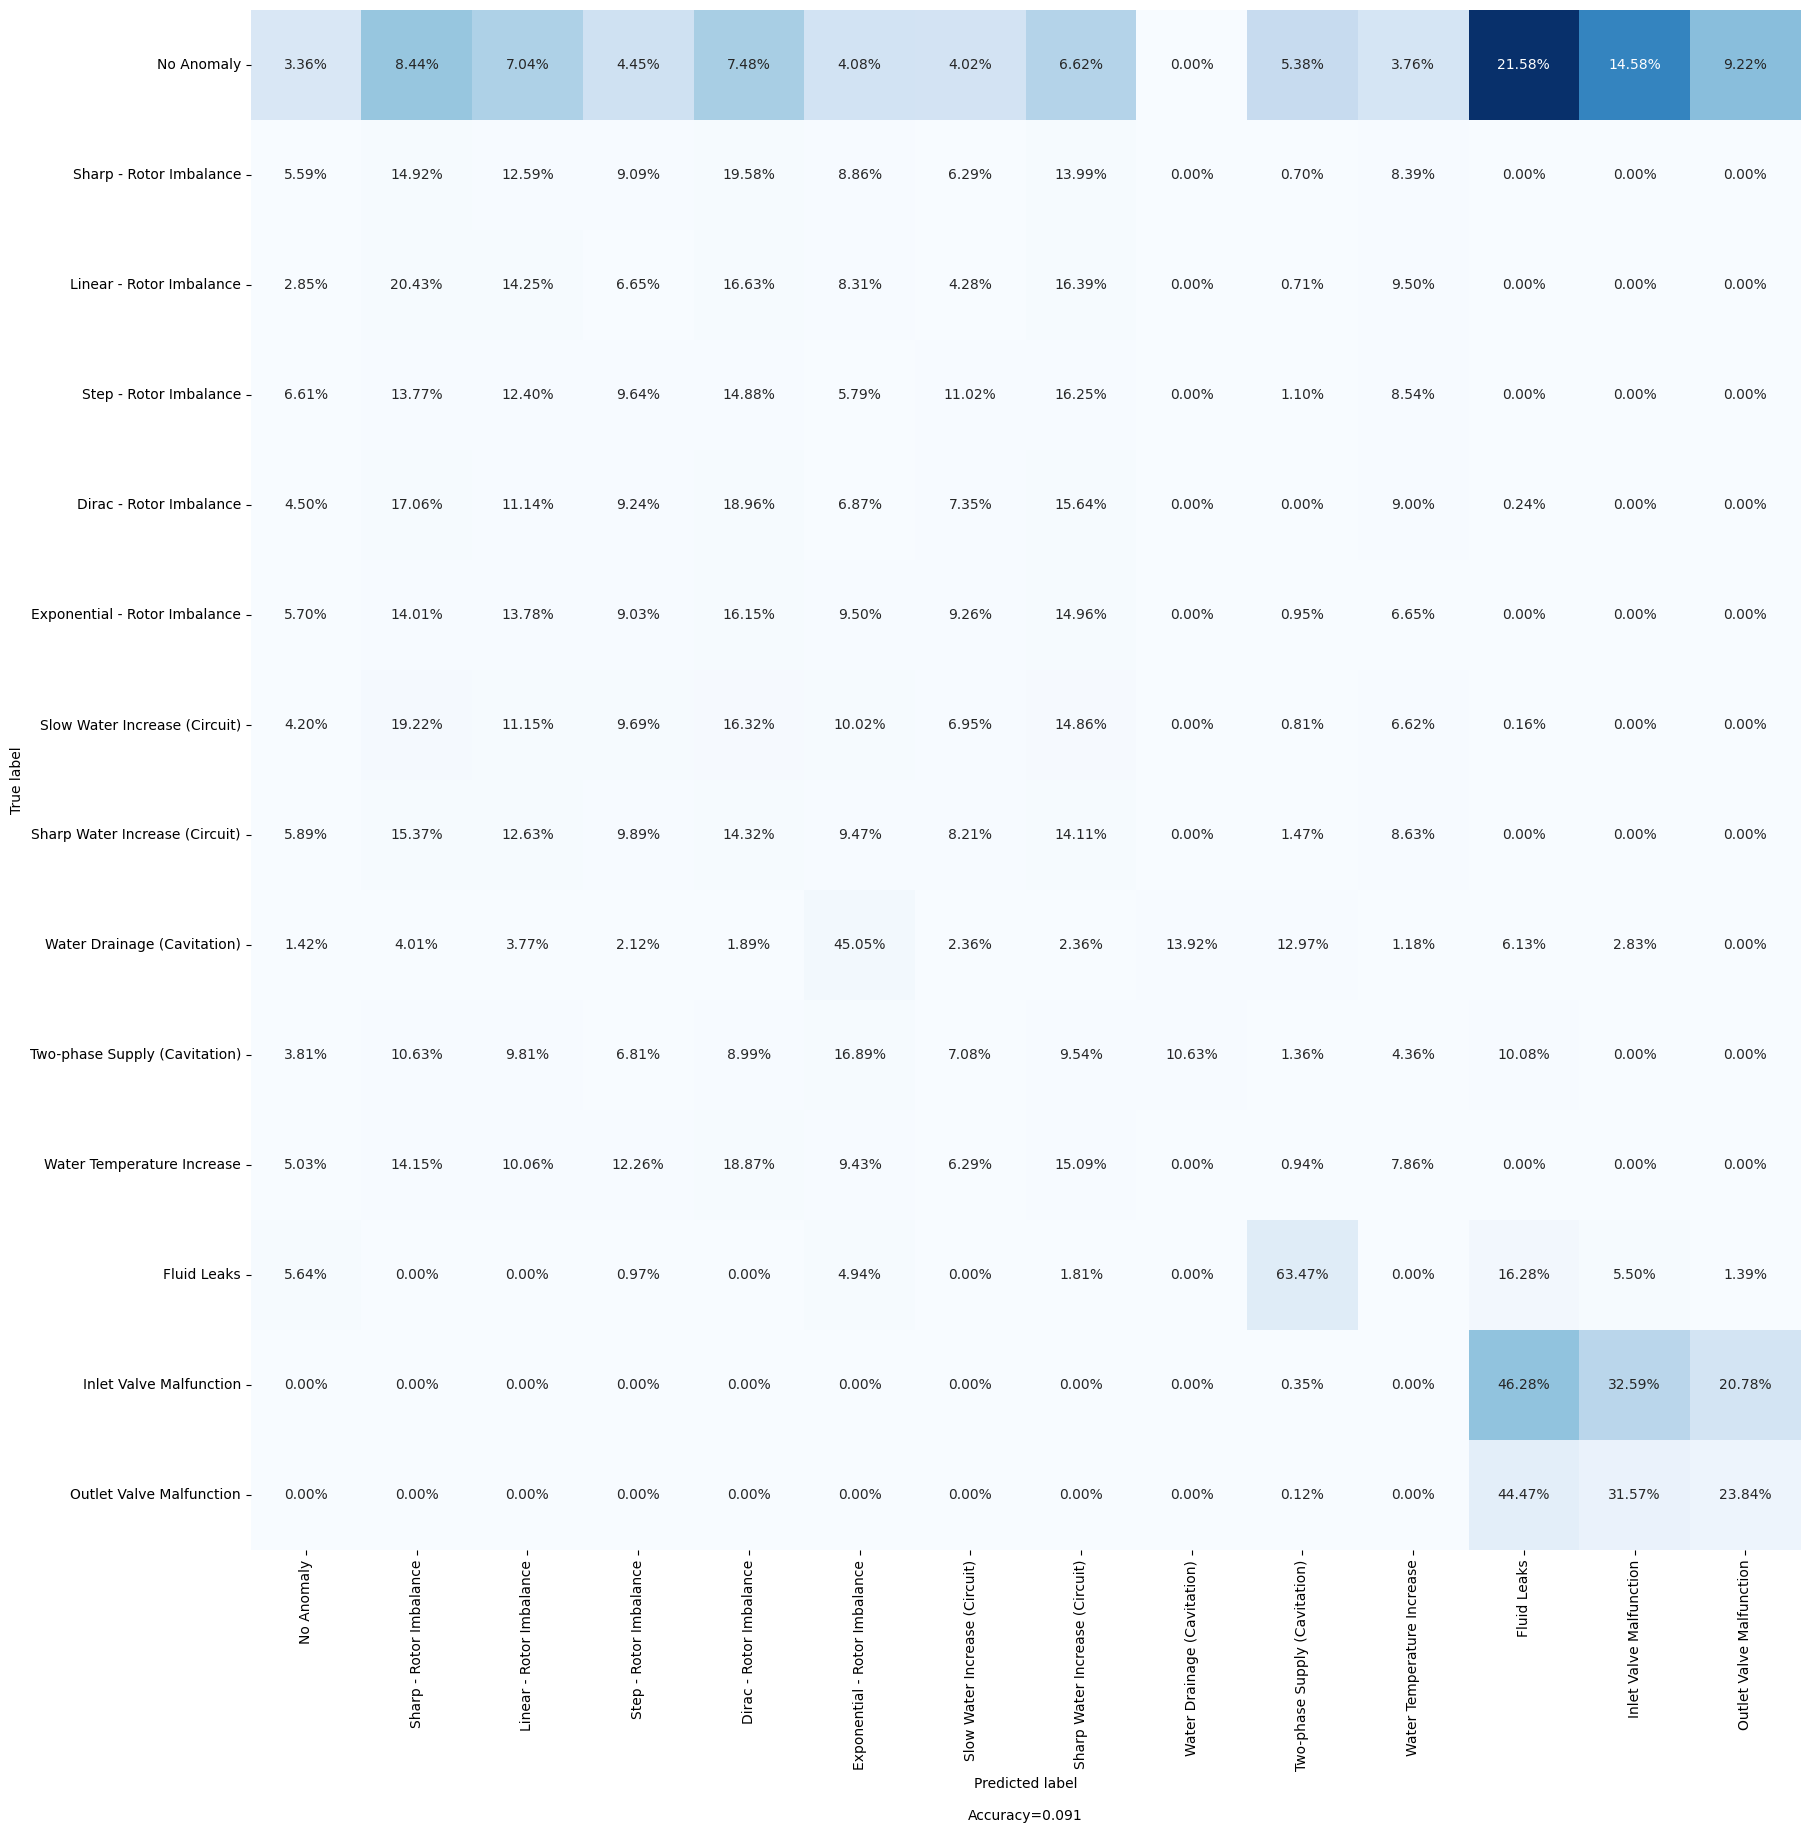

In [100]:
plot.make_confusion_matrix(
    confusion_matrix(dataframe_data.anomaly.values, kmeans_custom.labels_),
    categories=anomaly_names,
    count=False,
    cbar=False,
    figsize=(20, 20)
)

In [113]:
init_center = list()
for idx in dataframe.anomaly.unique():
    tmp = dataframe.iloc[np.where(dataframe.anomaly==idx)]
    tmp.drop(["anomaly", "description"], axis=1, inplace=True)
    tmp_mean = tmp.mean(axis=0)
    init_center.append([val.item() for val in tmp_mean.values])
    # break
init_center = np.asarray(init_center)

In [96]:
import numpy as np
from sklearn.cluster import KMeans

X = np.random.rand(100, 2)
initial_centers = np.array([[0.1, 0.1], [0.9, 0.9], [0.5, 0.5]])

# CORRECT: n_init must be 1 when init is an array
kmeans = KMeans(n_clusters=3, init=initial_centers, n_init=1, random_state=42)
kmeans.fit(X)
print("KMeans fitted successfully with custom init and n_init=1.")

# INCORRECT: This would raise an error if init is an array
# kmeans_bad = KMeans(n_clusters=3, init=initial_centers, n_init=10, random_state=42)
# kmeans_bad.fit(X)

KMeans fitted successfully with custom init and n_init=1.


In [ ]:
# init_center = [
#     [1.25690311e-01, 1.59902174e-01, 1.72548997e+00, 1.10089686e+00,8.02697519e+01, 2.66699463e+01, 2.29652896e+02, 8.09871462e+01,1.73751666e+02, 2.01813602e-02, 3.01591529e+00, 3.06745299e-02,5.59617793e+00, 3.42118627e-02, 5.35998057e+01, 1.50390270e+02,3.37650446e+02, 4.43666602e-01, 7.39331590e-01, 2.59023841e-04,2.98854901e-01, 8.21269106e-03, 3.39982676e-04, 8.96940487e-02,4.93504596e-03, 3.06743090e-01, 2.26631935e+01, 5.05826283e+01],
#     [6.31765723e-01, 7.34642473e-01, 2.43944593e+00, 1.14211405e+00,8.86130298e+01, 2.94010051e+01, 2.28134445e+02, 1.25910690e+02,9.83143214e+01, 9.07077997e-03, 3.01396059e+00, 4.64255865e-01,4.44142834e+00, 1.02876751e-01, 5.92120247e+01, 2.39678879e+02,4.75291451e+02, 5.42182070e-01, 8.60259307e-01, 3.68736794e-03,2.00196414e-01, 9.15682724e-03, 5.73326824e-03, 1.13410723e-01,4.43840559e-03, 2.84622471e-01, 3.94528478e+01, 6.82106719e+01],
#     [5.69463207e-01, 6.22265779e-01, 2.47124131e+00, 1.13482411e+00,8.84766596e+01, 2.96144732e+01, 2.29344461e+02, 1.26273304e+02,9.60829896e+01, 8.98771574e-03, 2.98762038e+00, 3.70501839e-01,4.50427244e+00, 5.28025724e-02, 5.88621865e+01, 2.38818310e+02,4.83411000e+02, 5.19351224e-01, 9.16371831e-01, 2.93758191e-03,1.92272010e-01, 8.82164971e-03, 6.33150689e-03, 1.23383306e-01,3.85619002e-03, 2.94364561e-01, 3.66095934e+01, 5.95124515e+01],
#     [5.42938937e-01, 6.09296595e-01, 2.39432974e+00, 1.13898696e+00,8.82880835e+01, 2.98376934e+01, 2.28409898e+02, 1.26618882e+02,1.00722767e+02, 8.99496223e-03, 2.95897537e+00, 3.44980729e-01,4.34259259e+00, 6.63576584e-02, 5.84503901e+01, 2.40381953e+02,4.67398323e+02, 5.55287600e-01, 8.89450901e-01, 2.72845046e-03,2.04161399e-01, 9.50112637e-03, 7.24338134e-03, 1.12758138e-01,5.64787879e-03, 2.93580165e-01, 3.67448808e+01, 7.28692048e+01],
#     [2.18126237e-01, 2.66328848e-01, 2.43610411e+00, 1.14633817e+00,8.83211360e+01, 2.99192960e+01, 2.28169171e+02, 1.27658581e+02,9.81337733e+01, 8.98004343e-03, 2.95198858e+00, 5.90442041e-02,4.37140323e+00, 4.82026114e-02, 5.84018400e+01, 2.43898159e+02,4.74321544e+02, 5.45055354e-01, 8.18431976e-01, 4.62543209e-04,1.98639780e-01, 9.33274595e-03, 2.15541103e-03, 1.26415659e-01,5.65309953e-03, 2.86349953e-01, 3.62213089e+01, 6.75479437e+01],
#     [5.85817964e-01, 6.53261473e-01, 2.46292689e+00, 1.11067748e+00,8.66857789e+01, 2.94330330e+01, 2.27151874e+02, 1.25583183e+02,9.68912667e+01, 8.84624682e-03, 2.94518690e+00, 3.96010412e-01,4.47675517e+00, 6.74435083e-02, 5.72527458e+01, 2.32431282e+02,4.77937418e+02, 5.22087432e-01, 8.95981760e-01, 3.15897934e-03,1.94780909e-01, 9.11864578e-03, 6.13565456e-03, 1.15124646e-01,4.61338717e-03, 3.25672019e-01, 3.87665810e+01, 7.22772259e+01],
#     [2.31675635e-01, 2.84255842e-01, 2.46761125e+00, 1.11140103e+00,8.57709470e+01, 3.14621099e+01, 2.26757690e+02, 1.29730711e+02,9.59939875e+01, 8.56825439e-03, 2.72812339e+00, 6.58770907e-02,4.32994672e+00, 5.25802068e-02, 5.43088372e+01, 2.40306551e+02,4.77420800e+02, 5.34326777e-01, 8.15002505e-01, 5.07842794e-04,1.90895026e-01, 9.84148978e-03, 7.32493325e-04, 1.14542488e-01,1.67657254e-02, 3.72626494e-01, 3.65845114e+01, 6.57040721e+01],
#     [2.36388173e-01, 2.99586162e-01, 2.43557278e+00, 1.10936561e+00,8.48828619e+01, 3.01333002e+01, 2.27526966e+02, 1.28605366e+02,9.85683982e+01, 8.62525613e-03, 2.81696962e+00, 7.08253402e-02,4.33001279e+00, 6.31979895e-02, 5.47495617e+01, 2.37823026e+02,4.73333036e+02, 5.43301386e-01, 7.89131715e-01, 5.50734243e-04,1.93292460e-01, 9.92302920e-03, 9.80224138e-04, 1.07089869e-01,6.88023579e-03, 3.79002779e-01, 3.72426106e+01, 7.12371854e+01],
#     [2.57187642e-01, 2.97155500e-01, 2.35743185e+00, 1.12666563e+00,8.54102660e+01, 2.93019193e+01, 2.27194840e+02, 4.07711678e+01,1.03507928e+02, 3.31021594e-01, 2.91485297e+00, 7.64686199e-02,1.54348291e+02, 3.99678585e-02, 5.61083467e+01, 7.58163836e+01,4.57757713e+02, 1.76855264e-01, 8.65466613e-01, 2.26082755e-02,2.05592883e-01, 3.15985103e-03, 1.55554250e-03, 9.93779434e-02,5.17133019e-03, 1.33362532e+01, 3.06338064e+01, 7.22967856e+01],
#     [2.50653935e-01, 2.93604193e-01, 2.29297752e+00, 1.13471376e+00,8.57006237e+01, 2.89106774e+01, 2.26129619e+02, 8.83330175e+01,1.07185803e+02, 2.22057367e-01, 2.96433796e+00, 7.36613940e-02,9.56016319e+01, 4.29502589e-02, 5.67899463e+01, 1.62475531e+02,4.44405867e+02, 3.66370292e-01, 8.53548861e-01, 1.71560180e-02,2.16785947e-01, 6.45039537e-03, 1.08621919e-03, 8.79165559e-02,3.75347139e-03, 4.37272294e+00, 3.11356903e+01, 5.74205733e+01],
#     [2.46410748e-01, 2.96615280e-01, 2.39600799e+00, 1.13362634e+00,8.63416302e+01, 3.28481560e+01, 2.27795956e+02, 1.29587994e+02,9.97730131e+01, 8.74949185e-03, 2.63242267e+00, 7.30977142e-02,4.22833816e+00, 5.02045314e-02, 5.34934742e+01, 2.44804610e+02,4.65695910e+02, 5.60821678e-01, 8.30810083e-01, 5.64088276e-04,1.97838456e-01, 1.04862964e-02, 1.09265651e-03, 1.04100088e-01,3.21519245e-02, 3.57982767e-01, 3.82516973e+01, 6.60606079e+01],
#     [8.07229954e-02, 1.31365479e-01, 1.58840143e+00, 1.01714476e+00,8.74328114e+01, 2.21147697e+01, 2.30032239e+02, 7.39402082e+01,1.55305248e+02, 1.37626012e-02, 3.95353586e+00, 1.06040553e-02,4.96532266e+00, 5.06424834e-02, 6.53180418e+01, 1.25342109e+02,3.11972097e+02, 4.39203445e-01, 6.14750362e-01, 1.43493200e-04,3.06212404e-01, 6.72567390e-03, 1.06627153e-04, 9.78980404e-02,3.77683507e-03, 3.20563491e-01, 2.17192244e+01, 5.43122704e+01],
#     [2.73787611e-02, 4.07053023e-02, 9.72509544e-01, 1.08413400e+00,6.99554825e+01, 2.50081256e+01, 2.30689371e+02, 2.95966203e+01,2.58704700e+02, 3.69090217e-02, 2.79668985e+00, 1.11476244e-03,7.68003226e+00, 1.33265412e-02, 4.49473569e+01, 5.35191765e+01,1.91450883e+02, 3.10091814e-01, 6.73030310e-01, 3.80192775e-05,4.05031757e-01, 6.89602762e-03, 2.14778157e-05, 6.53195690e-02,3.83262065e-03, 3.38505363e-01, 8.55061150e+00, 3.32786609e+01],
#     [2.76109250e-02, 3.98178342e-02, 9.63125784e-01, 1.06653360e+00,6.84213353e+01, 2.42209014e+01, 2.30180685e+02, 3.04197282e+01,2.60678455e+02, 3.51291682e-02, 2.82492327e+00, 1.09942188e-03,7.33059303e+00, 1.22069093e-02, 4.42004339e+01, 5.40706815e+01,1.89374382e+02, 3.18146271e-01, 6.94106826e-01, 3.62068443e-05,4.01804563e-01, 7.20308802e-03, 2.11225397e-05, 6.74432818e-02,3.69579786e-03, 3.56664830e-01, 9.18071496e+00, 3.17698936e+01]
# ]

In [117]:
dataframe_X.values.shape, init_center.shape

((49202, 28), (14, 28))

In [ ]:
kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), init=init_center, n_init=1) # n_init=1 when pre-defined

In [132]:
kmeans_custom.fit(dataframe.drop(["anomaly", "description"], axis=1).to_numpy())

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

KMeans(init=array([[1.25690311e-01, 1.59902174e-01, 1.72548997e+00, 1.10089686e+00,
        8.02697519e+01, 2.66699463e+01, 2.29652896e+02, 8.09871462e+01,
        1.73751666e+02, 2.01813602e-02, 3.01591529e+00, 3.06745299e-02,
        5.59617793e+00, 3.42118627e-02, 5.35998057e+01, 1.50390270e+02,
        3.37650446e+02, 4.43666602e-01, 7.39331590e-01, 2.59023841e-04,
        2.98854901e-01, 8.21269106e-03,...
        6.84213353e+01, 2.42209014e+01, 2.30180685e+02, 3.04197282e+01,
        2.60678455e+02, 3.51291682e-02, 2.82492327e+00, 1.09942188e-03,
        7.33059303e+00, 1.22069093e-02, 4.42004339e+01, 5.40706815e+01,
        1.89374382e+02, 3.18146271e-01, 6.94106826e-01, 3.62068443e-05,
        4.01804563e-01, 7.20308802e-03, 2.11225397e-05, 6.74432818e-02,
        3.69579786e-03, 3.56664830e-01, 9.18071496e+00, 3.17698936e+01]]),
       n_clusters=14, n_init=1)

### Isolation Forest

In [8]:
dataframe_X = dataframe.drop(columns=["anomaly", "description"])
dataframe_y = dataframe[["anomaly"]]

X_train, X_test, y_train, y_test = train_test_split(
                                                        dataframe_X.values, 
                                                        dataframe_y.values.ravel(), 
                                                        test_size=0.3, 
                                                        random_state=SEED, 
                                                        stratify=dataframe_y.values.ravel()
)
dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [9]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [10]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 4385 anomalies in test set.


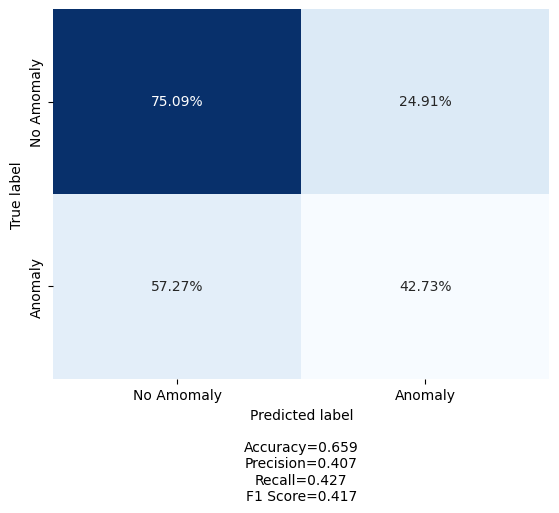

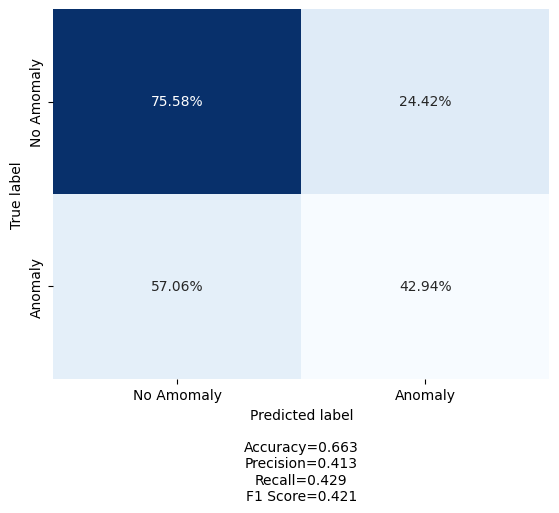

In [11]:
y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, train_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [12]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [13]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 133 anomalies in test set.


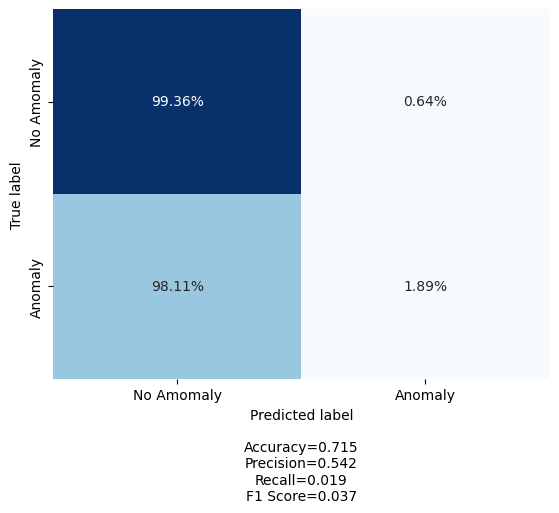

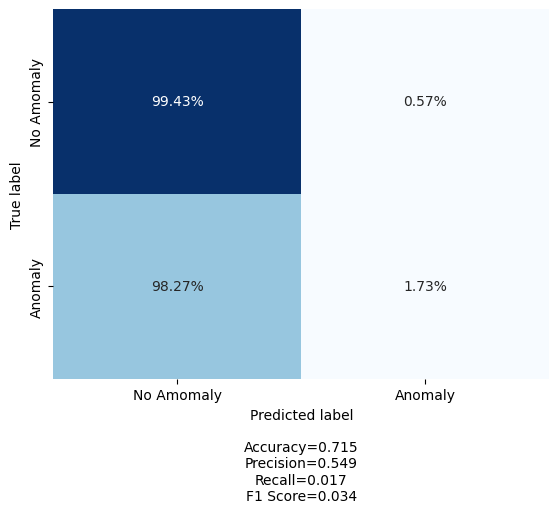

In [14]:
y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, train_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [15]:
# dataframe_no_anomaly = dataframe[dataframe["anomaly"] == 0]
# dataframe_no_anomaly.drop(columns=["anomaly", "description"], inplace=True)

In [16]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     if i[0] == 0: continue
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

In [17]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
#     if idx == 0: continue  # Skip the normal class (0)
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [18]:
# for idx, (center, distance) in enumerate(zip(initial_centers, distances), 1):
#     tmp = dataframe_no_anomaly.apply(lambda row: np.linalg.norm(row - center), axis=1)
#     per = np.where(tmp < distance, 1, 0).sum() / tmp.shape[0] * 100
#     print(f"{idx}, {anomaly_ids[idx]}, Percentage within distance: {per:.2f}%")

In [19]:
# dataframe_all = dataframe.drop(columns=["anomaly", "description"])
# dataframe_all.shape

In [20]:
# combined = zip(dataframe.anomaly.values, dataframe.description.values)
# sorted_pairs = sorted(combined, key=lambda pair: pair[0])

# anomaly_ids = dict()
# for i in sorted_pairs:
#     anomaly_ids[i[0]] = i[1]

# anomaly_names = [val for key, val in anomaly_ids.items()]

# for idx, name in anomaly_ids.items():
#     print(f"{idx}, {name}") 

In [21]:
# initial_centers, distances = list(), list()
# for idx in dataframe_data.anomaly.unique():
    
#     tmp = dataframe_data.iloc[np.where(dataframe_data.anomaly==idx)]
#     tmp.drop(columns=["anomaly"], inplace=True)

#     tmp_mean = tmp.mean(axis=0)
#     initial_centers.append(tmp_mean.values)

#     tmp["distance"] = tmp.apply(lambda row: np.linalg.norm(row - tmp_mean), axis=1)
#     distances.append(tmp.distance.median())

# initial_centers = np.array(initial_centers)
# distances = np.array(distances)

# initial_centers.shape, distances.shape

In [22]:
# for idx1, name in anomaly_ids.items():
#     tmp = dataframe[dataframe["anomaly"] == idx]
#     tmp.drop(columns=["anomaly", "description"], inplace=True)

#     for idx2, (center, distance) in enumerate(zip(initial_centers, distances)):
#         tmp2 = tmp.apply(lambda row: np.linalg.norm(row - center), axis=1)
#         per = np.where(tmp2 < distance, 1, 0).sum() / tmp2.shape[0] * 100
#         print(f"{anomaly_ids[idx1]}, {anomaly_ids[idx2]}, Percentage within distance: {per:.2f}%")